# Multiple Iterative Imputation

🧪 Step 1: Create a Simple Dataset

In [1]:
import pandas as pd
import numpy as np

```bash

Imagine an e-commerce dataset:

sales → target (missing)
price
marketing_spend
store_visits
discount

In [2]:
data = {
    'sales' : [200, 350, np.nan, 500, np.nan, 420, 380, np.nan, 610, 450],
    'price' : [20, 25, 22, 30, 28, 26, 24, 23, 35, 27],
    'marketing_spend' : [1000, 1500, 1200, 2000, 1800, 1600, 1400, 1300, 2200, 1700],
    'store_visits' : [300, 500, 400, 700, 650, 600, 550, 450, 800, 620],
    'discount' : [5, 10, 7, 15, 12, 10, 8, 6, 18, 11]
}
df = pd.DataFrame(data)
print(df)

   sales  price  marketing_spend  store_visits  discount
0  200.0     20             1000           300         5
1  350.0     25             1500           500        10
2    NaN     22             1200           400         7
3  500.0     30             2000           700        15
4    NaN     28             1800           650        12
5  420.0     26             1600           600        10
6  380.0     24             1400           550         8
7    NaN     23             1300           450         6
8  610.0     35             2200           800        18
9  450.0     27             1700           620        11


In [3]:
df.isnull().sum()

sales              3
price              0
marketing_spend    0
store_visits       0
discount           0
dtype: int64

🔍 2. Visualize Missing Values

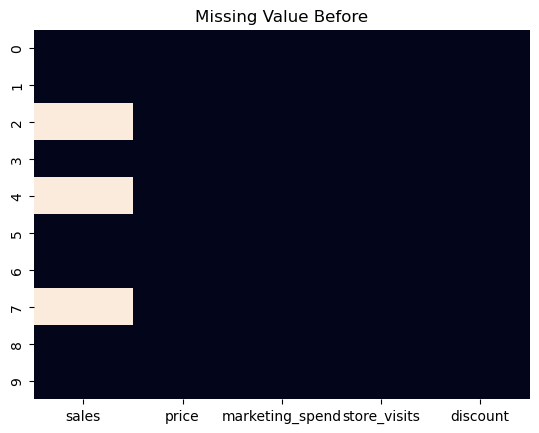

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Before")
plt.show()

👉 Missing values are in sales

📊 3. Understand Relationships

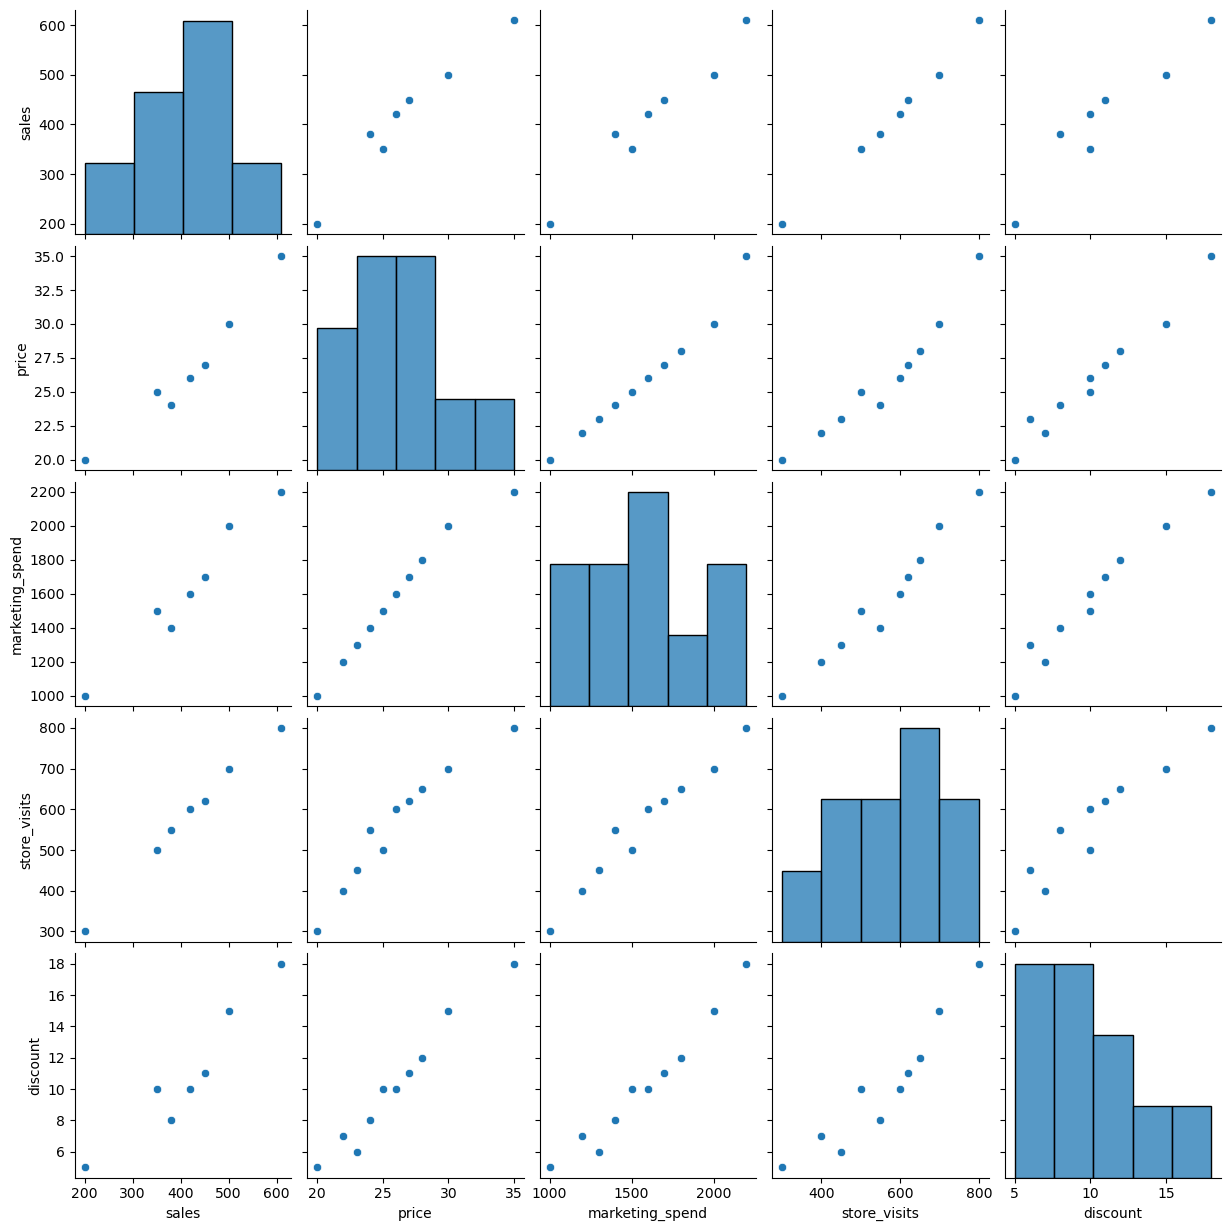

In [5]:
sns.pairplot(df)
plt.show()

```bash

👉 You may notice:

More marketing → more sales 📈
More visits → more sales
Higher discount → boosts sales
Higher price → may reduce sales

🧠 4. Apply Iterative Imputer

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42)

df_imputed =  df.copy()
df_imputed[:] = imputer.fit_transform(df)
df_imputed


,sales,price,marketing_spend,store_visits,discount
0,200.000000,20,1000,300,5
1,350.000000,25,1500,500,10
2,271.273511,22,1200,400,7
3,500.000000,30,2000,700,15
4,470.995666,28,1800,650,12
5,420.000000,26,1600,600,10
6,380.000000,24,1400,550,8
7,309.599247,23,1300,450,6
8,610.000000,35,2200,800,18
9,450.000000,27,1700,620,11


🔍 5. After Imputation

In [7]:
print(df_imputed.isnull().sum())

sales              0
price              0
marketing_spend    0
store_visits       0
discount           0
dtype: int64


📊 6. Compare Before vs After (Sales)

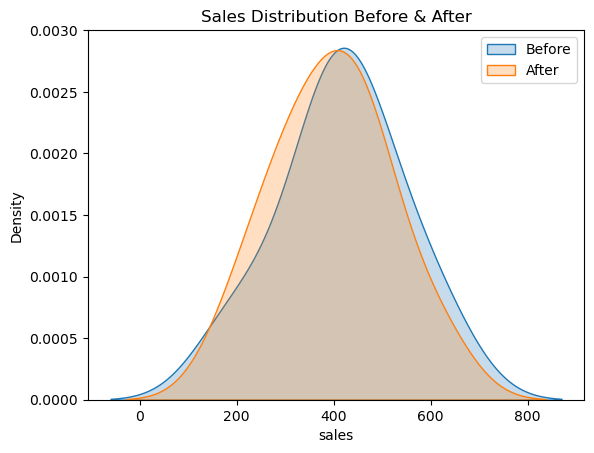

In [8]:
sns.kdeplot(df['sales'], label='Before', fill=True)
sns.kdeplot(df_imputed['sales'], label='After', fill=True)
plt.legend()
plt.title("Sales Distribution Before & After")
plt.show()


🧾 7. See Predicted Values

In [9]:
comparison = pd.DataFrame({
    'Before': df['sales'],
    'After': df_imputed['sales']
})

print(comparison)

   Before       After
0   200.0  200.000000
1   350.0  350.000000
2     NaN  271.273511
3   500.0  500.000000
4     NaN  470.995666
5   420.0  420.000000
6   380.0  380.000000
7     NaN  309.599247
8   610.0  610.000000
9   450.0  450.000000


🧠 What the Model Learned (Intuition)

```bash
sales = f(price, marketing_spend, store_visits, discount)

So for a missing row like:

price = 22
marketing = 1200
visits = 400
discount = 7


It thinks:

👉 “Moderate marketing + medium visits → moderate sales”

```bash

⚡ Pro Insight

IterativeImputer is basically doing:

“Given marketing, visits, price, and discount… what should sales be?”

That’s very close to how real business forecasting models work.